# Task II: Convolutional Neural Networks — AI vs. Human Art Classifier

**Dataset:** `Art_shuffled/` — 539 AI-generated images, 436 real art images (975 total)
**Model:** EfficientNetB0 via transfer learning

## Data Analysis

**Class distribution:** The dataset contains 539 AI-generated and 436 real art images. This is a mild imbalance of roughly 55/45. Note that a naive classifier that always predicts 'AI' would achieve ~55% accuracy, so our baseline for meaningful performance is clearly above that.

**Dataset size:** With fewer than 1000 images total, this is a small dataset. Training a deep CNN from scratch on this scale would almost certainly lead to severe overfitting. This motivates the use of transfer learning from a pretrained model.

In [10]:
from pathlib import Path
from PIL import Image
import os

dataset_path = 'Art_shuffled/'

ai_count   = len(os.listdir(os.path.join(dataset_path, 'AiArtData/')))
real_count  = len(os.listdir(os.path.join(dataset_path, 'RealArt/')))

def convert_unsupported_images(dataset_path):
    to_fix = []
    for path in Path(dataset_path).rglob('*.png'):
        from PIL import Image as PILImage
        img = PILImage.open(path)
        if img.mode in ('P', 'PA'):
            to_fix.append(path)

    for path in to_fix:
        img = PILImage.open(path).convert('RGB')
        img.save(path)
    print(f"Fixed {len(to_fix)} palett-pictures")

convert_unsupported_images('Art_shuffled/')

print(f"AI images:    {ai_count}")
print(f"Real images:  {real_count}")
print(f"Total:        {ai_count + real_count}")
print(f"Class ratio:  {ai_count / (ai_count + real_count):.2%} AI / {real_count / (ai_count + real_count):.2%} Real")

Fikset 0 palettbilder
AI images:    539
Real images:  436
Total:        975
Class ratio:  55.28% AI / 44.72% Real


## Data Preprocessing and Augmentation

**Image size:** EfficientNetB0 expects 224×224 input, so all images are resized accordingly.

**Augmentation:** Because the dataset is small, we apply light augmentation during training to artificially increase variety and reduce overfitting:
- Rotation (±15°):
- Horizontal flip:
- Zoom (±10%):

**Validation split:** 20% of data is held out for validation (752 training / 186 validation images). The same `ImageDataGenerator` is used with `subset` parameter to ensure consistent splitting.

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_data = train_gen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42
)

print("Class indices:", train_data.class_indices)

Found 781 images belonging to 2 classes.
Found 194 images belonging to 2 classes.
Class indices: {'AiArtData': 0, 'RealArt': 1}


## Model Architecture — EfficientNetB0

### Choice of pretrained model

We use **EfficientNetB0** pretrained on ImageNet as our base model.

- **Compound scaling:** EfficientNet models scale depth, width, and resolution jointly, giving strong performance per parameter. B0 is the smallest variant, making it appropriate for our compute constraints without sacrificing too much capacity.
- **Small dataset suitability:** With fewer than 1000 images, training a deep network from scratch would overfit severely. Transfer learning leverages ImageNet features that transfer well to art images.
- **Precedent:** EfficientNet has strong benchmark performance on image classification tasks at this scale.

### Architecture

The custom head added on top of the frozen base consists of:
- `GlobalAveragePooling2D` — reduces spatial feature maps to a single vector per feature, avoiding flattening which would produce very large parameter counts
- `Dense(128, relu)` — learns task-specific combinations of EfficientNet features
- `Dropout(0.3)` — regularization to reduce overfitting in the head
- `Dense(1, sigmoid)` — binary output (0 = AI art, 1 = Real art)

In [12]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model   = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Training the Classification Head

In the first training phase, the EfficientNetB0 base is frozen (its weights are not updated). Only the custom head is trained. This is practice allows the new layers to adapt to the task without disrupting the pretrained ImageNet features.

**Optimizer:** Adam with lr=1e-3. A relatively high learning rate is appropriate here since only the small head is being trained and convergence should be fast.

**EarlyStopping:** We monitor `val_loss` with a patience of 3 epochs. If validation loss does not improve for 3 consecutive epochs, training stops automatically. `restore_best_weights=True` ensures we keep the weights from the best epoch, not the final one.

In [13]:
early_stop_phase1 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_phase1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop_phase1]
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.6850 - loss: 0.5873 - val_accuracy: 0.6856 - val_loss: 0.5570
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.8220 - loss: 0.3946 - val_accuracy: 0.7320 - val_loss: 0.4970
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8476 - loss: 0.3337 - val_accuracy: 0.7526 - val_loss: 0.5133
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8963 - loss: 0.2781 - val_accuracy: 0.7268 - val_loss: 0.5022
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9257 - loss: 0.2399 - val_accuracy: 0.7680 - val_loss: 0.5093
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


## Fine-Tuning the Top Layers of the Base Model

In the second phase, we unfreeze the last 20 layers of the EfficientNetB0 base and continue training. This allows the model to adapt higher-level ImageNet features toward features more relevant to distinguishing AI from human art. This could be brushstroke regularity, noise distribution, stylistic consistency etc.

Earlier layers capture low-level features like edges and textures that transfer well from ImageNet. Deeper layers are more task-specific. Unfreezing too many layers risks overfitting and is slower to train, however unfreezing too few limits the model's ability to specialise.

**Optimizer:** Adam with lr=1e-5. A much lower learning rate is important here. Updating the pretrained weights too aggressively would destroy the learned representations.

**EarlyStopping:** Applied again with patience=3 on val_loss.

In [14]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

early_stop_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop_phase2]
)

# Save model locally in the same directory as the notebook
model.save('art_classifier.keras')
print("Model saved to art_classifier.keras")

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.8259 - loss: 0.4005 - val_accuracy: 0.7371 - val_loss: 0.4739
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8643 - loss: 0.3778 - val_accuracy: 0.7423 - val_loss: 0.5021
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8464 - loss: 0.3837 - val_accuracy: 0.7629 - val_loss: 0.4958
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8540 - loss: 0.3725 - val_accuracy: 0.7423 - val_loss: 0.4965
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.
Model saved to art_classifier.keras


## Training History Visualisation

Plotting the training and validation accuracy/loss across both phases helps us diagnose overfitting and assess whether EarlyStopping triggered at the right point.

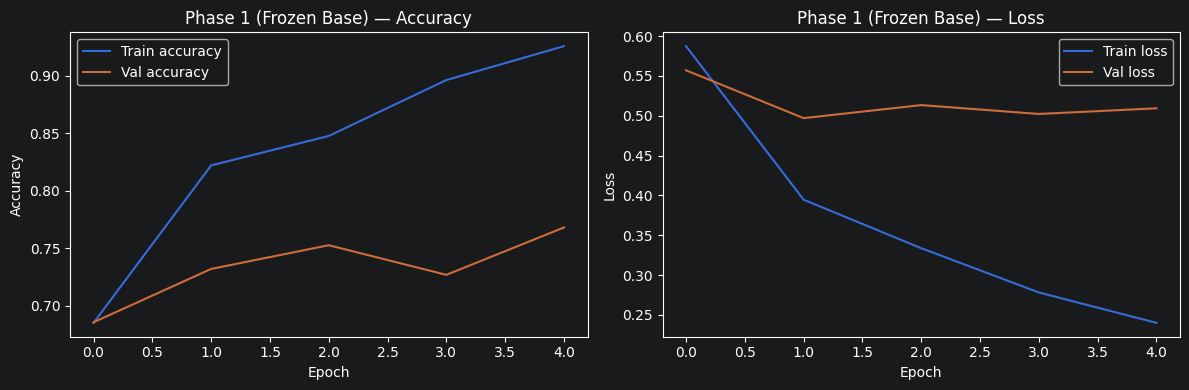

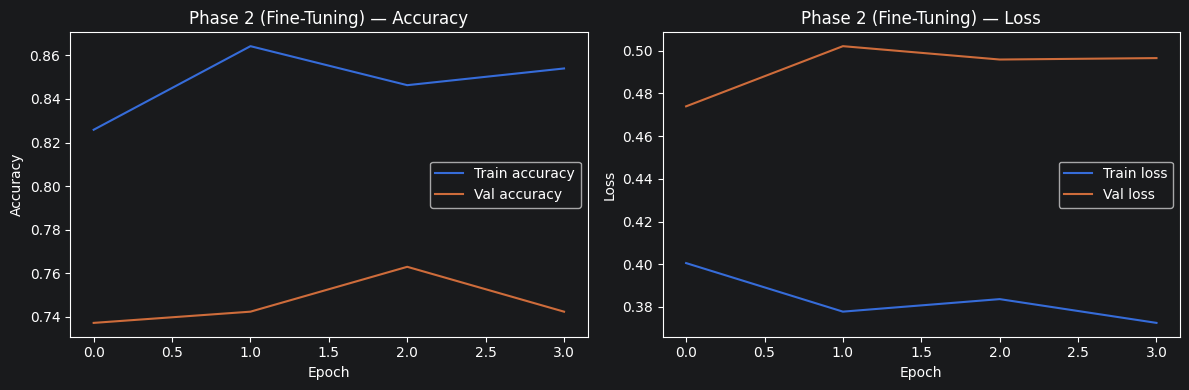

In [15]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['accuracy'],     label='Train accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val accuracy')
    ax1.set_title(f'{title_prefix} — Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'],     label='Train loss')
    ax2.plot(history.history['val_loss'], label='Val loss')
    ax2.set_title(f'{title_prefix} — Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, 'Phase 1 (Frozen Base)')
plot_history(history_phase2, 'Phase 2 (Fine-Tuning)')

## Confusion Matrix and Classification Report

Accuracy alone is an incomplete metric. We also compute a confusion matrix and precision/recall/F1 to understand whether errors are distributed evenly across classes or skewed.

Given the mild class imbalance, F1-score is a more informative summary than accuracy alone. A model that simply predicts 'AI' for every image would achieve ~55% accuracy, which is well below our model's performance, confirming it has learned meaningful features.

Found 194 images belonging to 2 classes.
              precision    recall  f1-score   support

      AI Art       0.74      0.84      0.79       107
    Real Art       0.76      0.63      0.69        87

    accuracy                           0.75       194
   macro avg       0.75      0.74      0.74       194
weighted avg       0.75      0.75      0.74       194



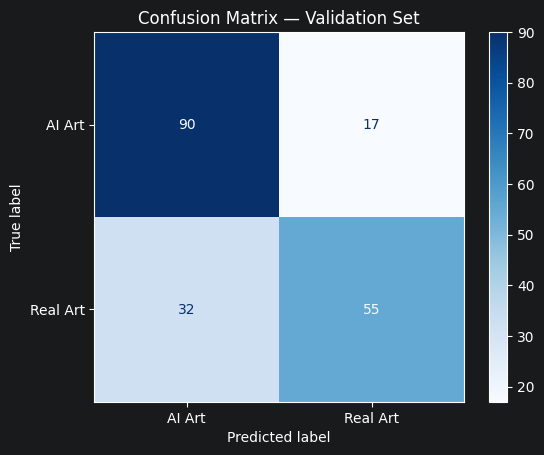

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator

eval_gen = ImageDataGenerator(validation_split=0.2)

eval_data = eval_gen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42,
    shuffle=False   #
)

y_pred_probs = model.predict(eval_data, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = eval_data.classes

print(classification_report(y_true, y_pred, target_names=['AI Art', 'Real Art']))

cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['AI Art', 'Real Art'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Validation Set')
plt.show()

## Classifying 5 New Images

For Task 2b we test the trained model on five AI-generated images stored locally in `task2b_aiart_images/`.  
Since all five images are AI-generated, the true label for every image is `AiArtData` (class index 0).

The trained model is loaded from the local file `art_classifier.keras` produced in Phase 2 above.  
Each image is resized to 224×224 and loaded as RGB, matching the preprocessing used during training.  
No manual pixel rescaling is applied. EfficientNetB0 includes its own internal preprocessing when called with pretrained ImageNet weights.

The model outputs a sigmoid score:
- < 0.5 is predicted AI-generated
- ≥ 0.5 is predicted human-made

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

MODEL_PATH    = Path('art_classifier.keras')
AI_IMAGE_DIR  = Path('task2b_aiart_images')
IMG_SIZE      = (224, 224)
SUPPORTED_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

assert MODEL_PATH.exists(),   f"Model not found: {MODEL_PATH}"
assert AI_IMAGE_DIR.exists(), f"Image folder not found: {AI_IMAGE_DIR}"

if 'model' not in dir() or model is None:
    model = load_model(MODEL_PATH, compile=False)
    print('Loaded model from', MODEL_PATH)
else:
    print('Using model already in memory.')

ai_image_paths = sorted(
    p for p in AI_IMAGE_DIR.rglob('*')
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXT
)

print(f'Found {len(ai_image_paths)} images in {AI_IMAGE_DIR}')
for p in ai_image_paths:
    print(' ', p)

Using model already in memory.
Found 5 images in task2b_aiart_images
  task2b_aiart_images/aiart.jpeg
  task2b_aiart_images/aiart.webp
  task2b_aiart_images/aiart1.jpeg
  task2b_aiart_images/aiart2.png
  task2b_aiart_images/airart3.jpeg


In [18]:
class_indices  = {'AiArtData': 0, 'RealArt': 1}
index_to_class = {v: k for k, v in class_indices.items()}

def prepare_image(path):
    img   = load_img(path, target_size=IMG_SIZE)
    array = img_to_array(img)
    return array

image_batch      = np.stack([prepare_image(p) for p in ai_image_paths])
prob_real        = model.predict(image_batch, verbose=0).reshape(-1)
predicted_indices = (prob_real >= 0.5).astype(int)

# All images are AI-generated
true_labels  = ['AiArtData'] * len(ai_image_paths)
true_indices = [class_indices[l] for l in true_labels]

results = pd.DataFrame({
    'image':               [p.name for p in ai_image_paths],
    'true_label':          true_labels,
    'probability_real_art': prob_real,
    'predicted_label':     [index_to_class[i] for i in predicted_indices],
})
results['correct']    = results['true_label'] == results['predicted_label']
results['confidence'] = np.where(
    predicted_indices == 1,
    results['probability_real_art'],
    1 - results['probability_real_art']
)

accuracy = accuracy_score(true_indices, predicted_indices)
print(f'Accuracy on {len(ai_image_paths)} new images: {accuracy:.2%}')
display(results)

print(classification_report(
    true_indices, predicted_indices,
    labels=[0, 1],
    target_names=[index_to_class[0], index_to_class[1]],
    zero_division=0,
))

/home/gromit/INFO284/venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Accuracy on 5 new images: 100.00%


,image,true_label,probability_real_art,predicted_label,correct,confidence
0,aiart.jpeg,AiArtData,0.021446,AiArtData,True,0.978554
1,aiart.webp,AiArtData,0.041249,AiArtData,True,0.958751
2,aiart1.jpeg,AiArtData,0.018982,AiArtData,True,0.981018
3,aiart2.png,AiArtData,0.041201,AiArtData,True,0.958799
4,airart3.jpeg,AiArtData,0.235345,AiArtData,True,0.764655


              precision    recall  f1-score   support

   AiArtData       1.00      1.00      1.00         5
     RealArt       0.00      0.00      0.00         0

    accuracy                           1.00         5
   macro avg       0.50      0.50      0.50         5
weighted avg       1.00      1.00      1.00         5



/home/gromit/INFO284/venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


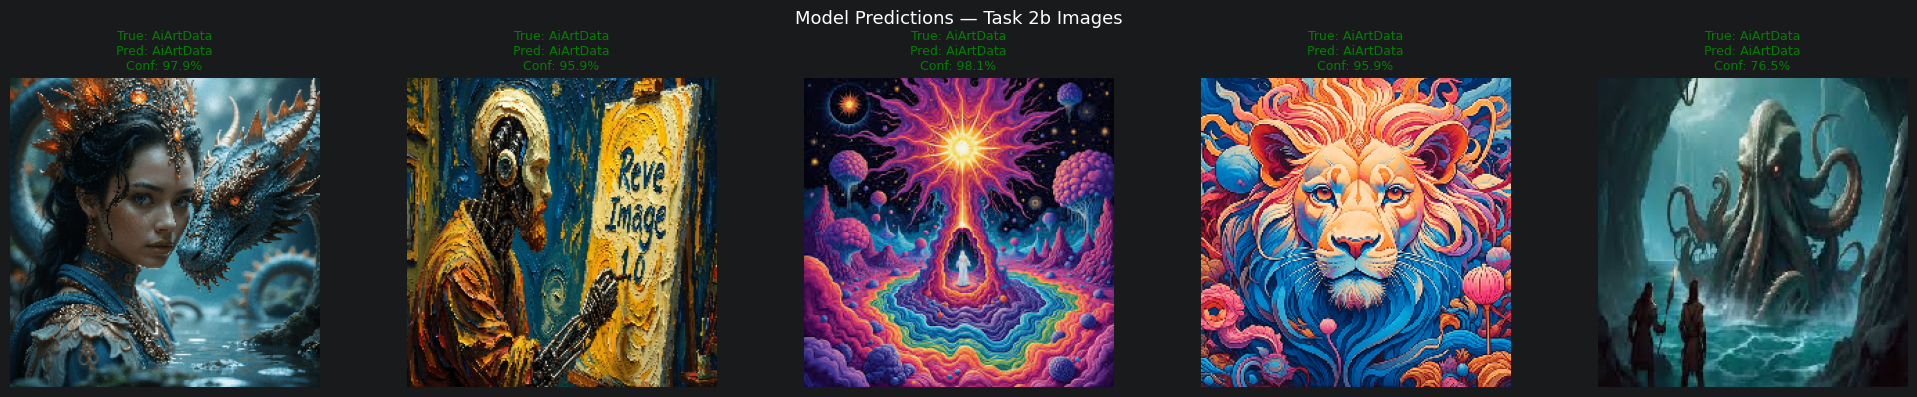

In [19]:
fig, axes = plt.subplots(1, len(ai_image_paths), figsize=(4 * len(ai_image_paths), 4))
if len(ai_image_paths) == 1:
    axes = [axes]

for ax, image_path, (_, row) in zip(axes, ai_image_paths, results.iterrows()):
    ax.imshow(load_img(image_path, target_size=IMG_SIZE))
    ax.axis('off')
    color = 'green' if row['correct'] else 'red'
    ax.set_title(
        f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.1%}",
        color=color, fontsize=9
    )

plt.suptitle('Model Predictions — Task 2b Images', fontsize=13)
plt.tight_layout()
plt.show()

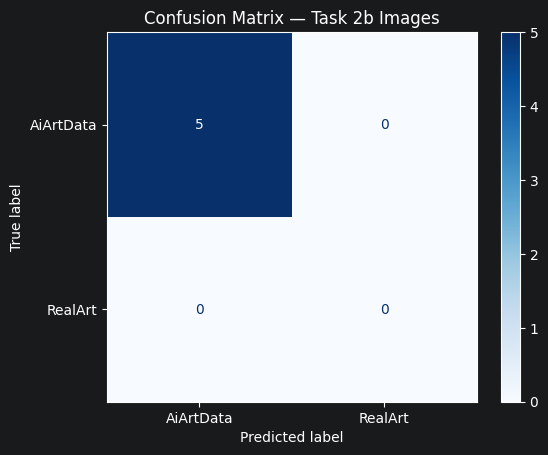

In [20]:
cm   = confusion_matrix(true_indices, predicted_indices, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[index_to_class[0], index_to_class[1]])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Task 2b Images')
plt.show()

## Summary and Discussion

### Results

The model achieves 75% validation accuracy on the held-out validation set (194 images). The best validation accuracy observed during training was 77.8%, from which EarlyStopping restored weights. The small gap between this and the final evaluation score reflects normal variation between the shuffled training generator and the fixed evaluation set. Given the small dataset size and the inherent difficulty of the task, 75% is a reasonable result.

### Class-wise performance

The classification report reveals an asymmetry between classes:
- AI Art (precision 74%, recall 84%) — the model is effective at detecting AI-generated images, but at the cost of misclassifying some real images as AI
- Real Art (precision 76%, recall 63%) — the model is more cautious here, missing 37% of genuine human-made images

This asymmetry is consistent with the mild class imbalance (55% AI, 45% real): the model learns a slight bias toward the majority class.

### Overfitting analysis

The training curves show a moderate overfitting pattern: training accuracy climbs to ~86% while validation accuracy plateaus around 77–79%. This gap is smaller than might be expected for a dataset of this size, which suggests the regularization measures were effective. EarlyStopping triggered early in both phases, after epoch 5 in Phase 1 and epoch 4 in Phase 2, preventing further divergence between training and validation performance.

Mitigation strategies applied:
- **Dropout (0.3)** in the classification head
- **Data augmentation** (rotation, horizontal flip, zoom)
- **EarlyStopping** with `restore_best_weights=True`

Further improvements that were not pursued due to resource constraints:
- More aggressive augmentation (color jitter, random cropping)
- L2 weight regularization in the dense layer
- A larger dataset would be the most impactful fix

### Fine-tuning assessment

Phase 2 fine-tuning produced only marginal gains over Phase 1, with EarlyStopping restoring weights from epoch 1 of Phase 2. Effectively the model improved very little during fine-tuning. This suggests the frozen ImageNet features were already well-suited to the task, and that the primary bottleneck is dataset size rather than feature quality.

### Consequences and limitations

Deployed in a real context, a 75% accurate classifier would misclassify 1 in 4 images. For a task like art attribution, which can have real consequences for artists, galleries, or copyright proceedings, this error rate is non-trivial. The model should be treated as a supporting tool rather than a definitive classifier. Additionally, the model was trained on a specific distribution of AI-generated art; it may not generalize well to images from newer generative models not represented in the training data.